# Шаг 19. Построение визуализации

Будут построены следующие визуализации:

1. **ABC-анализ производителей**: столбчатая диаграмма Топ-30 брендов с цветовой кодировкой категорий (A, B, C) для оценки поляризации рынка.
2. **Динамика рынка по десятилетиям**: график с двойной осью (количество наборов и средний рейтинг), показывающий эволюцию индустрии.
3. **Связь размера набора и рейтинга**: сравнение среднего качества в зависимости от количества фигур в коробке.
4. **Тепловая карта покрытия**: срез плотности релизов по годам (для примера с 1939 по 1945) и национальностям для выявления популярных тем и «белых пятен».
5. **RFM-анализ (пузырьковая диаграмма)**: оценка актуальных хитов по трём осям: давность релиза, качество и частота выпусков.
6. **Карта исторических периодов**: столбчатая диаграмма Топ-5 национальностей для каждой эпохи, отсортированная строго по хронологии (от Древнего мира к Современности).
7. **Адаптированный XYZ-анализ**: распределение пар «производитель–национальность» по категориям стабильности присутствия (X, Y, Z), показывающее надёжность поставок нишевых тем.

✅ Все данные успешно загружены.

=== 1. ABC-анализ производителей ===


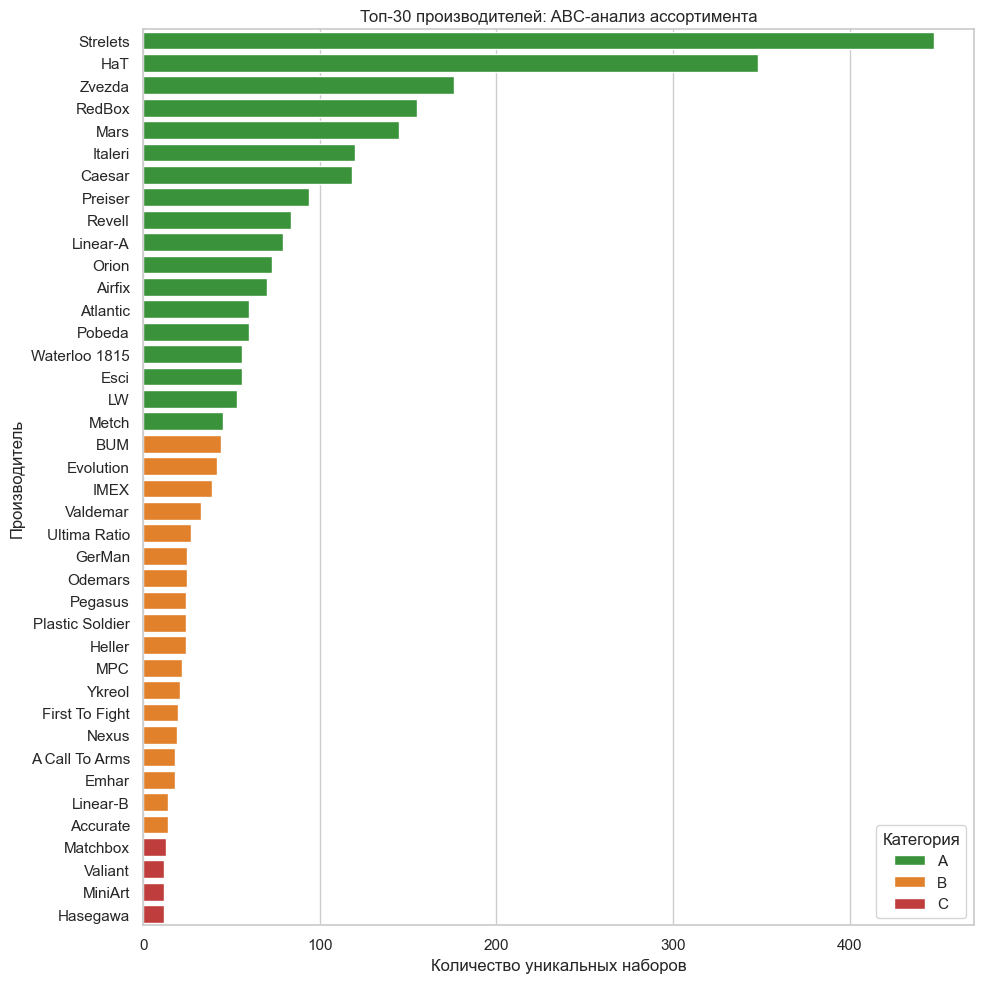


=== 2. Динамика рынка по десятилетиям ===


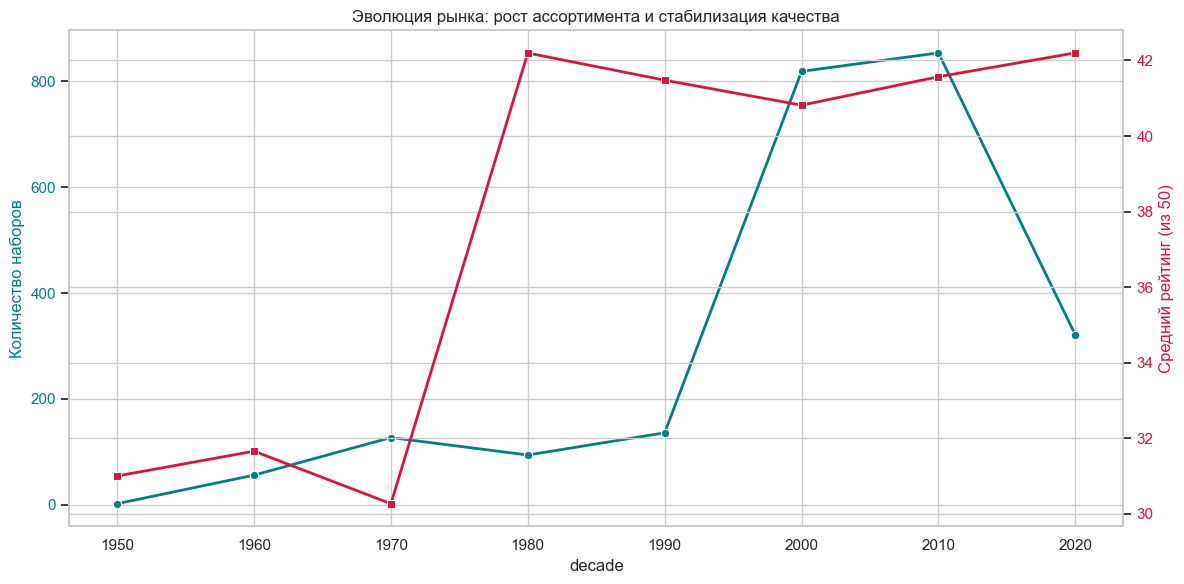


=== 3. Связь размера набора и его качества ===


C:\Users\mi\AppData\Local\Temp\ipykernel_21316\1389598288.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_figures, x='figure_category', y='avg_rating', order=order_fig, palette="Blues_r")


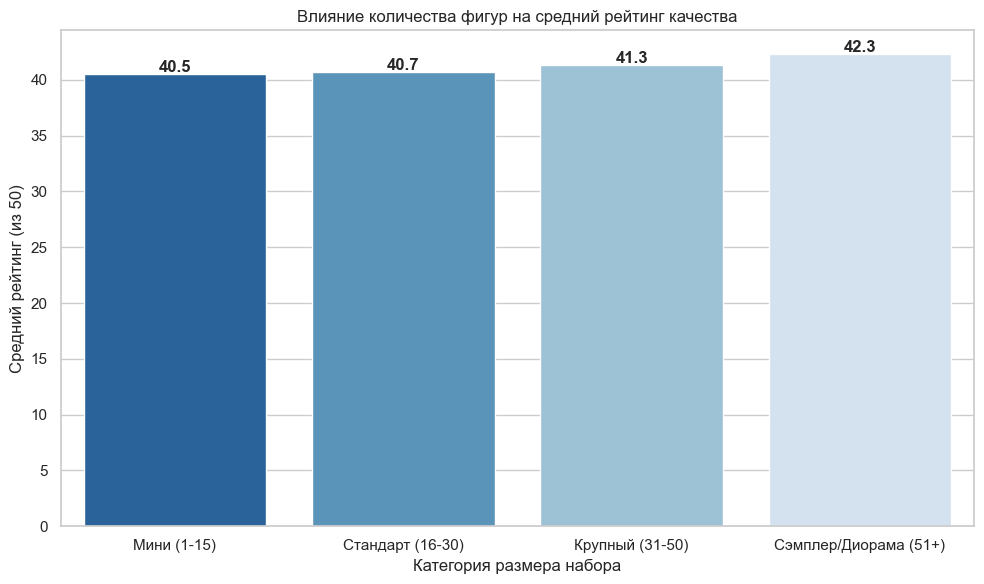


=== 4. Тепловая карта покрытия (1939–1945) ===


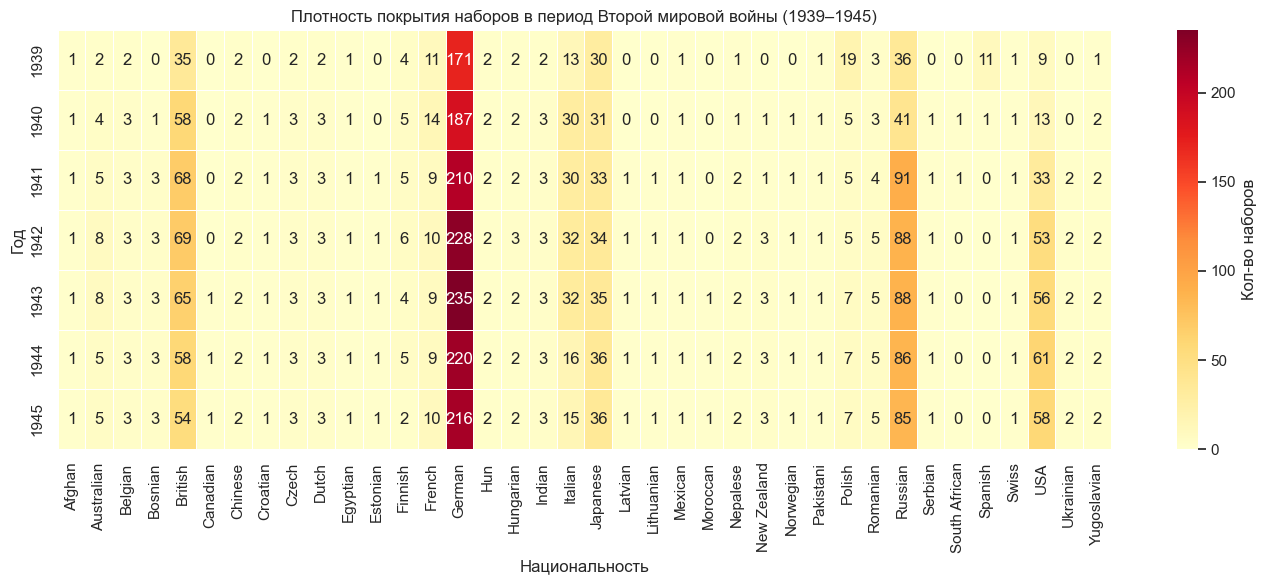


=== 5. RFM-анализ: актуальные хиты ===


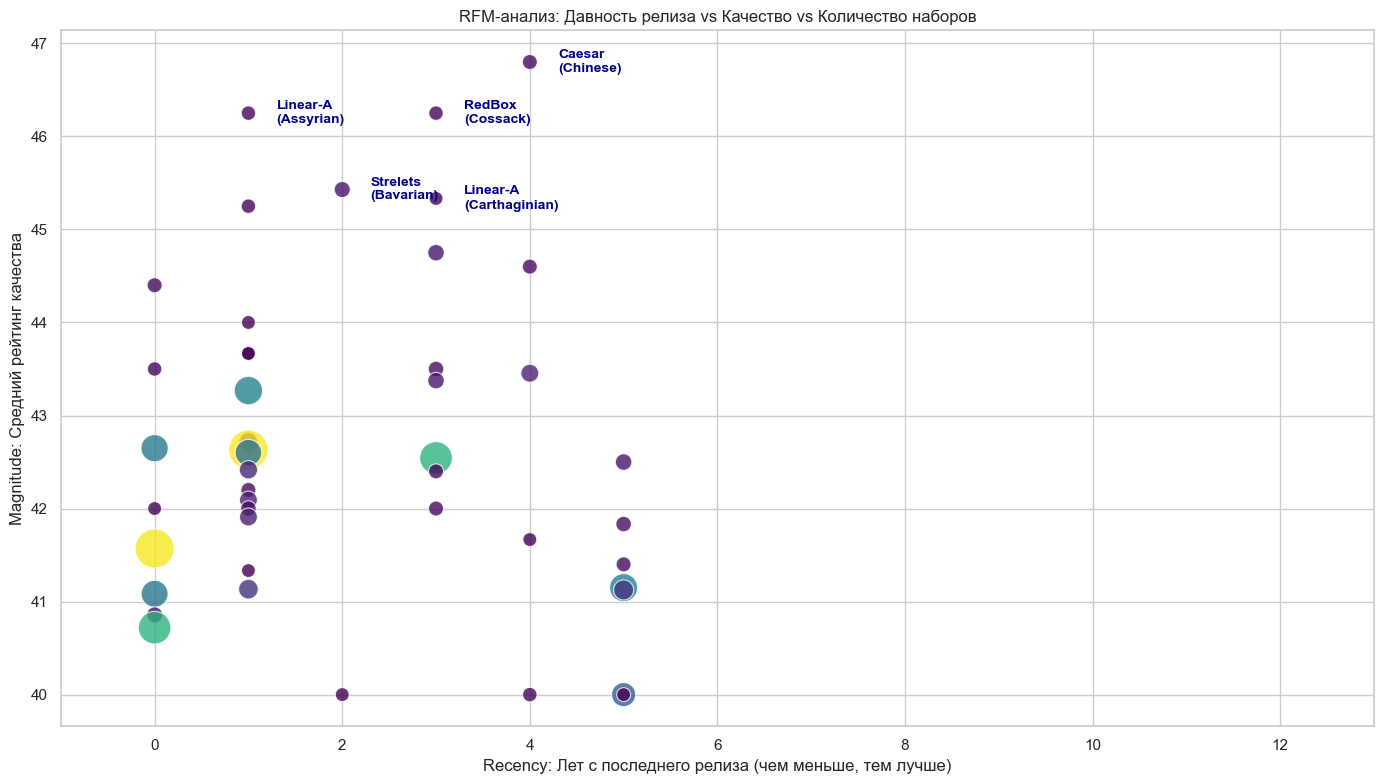


=== 6. Карта исторических периодов: Топ-5 национальностей по эпохам ===


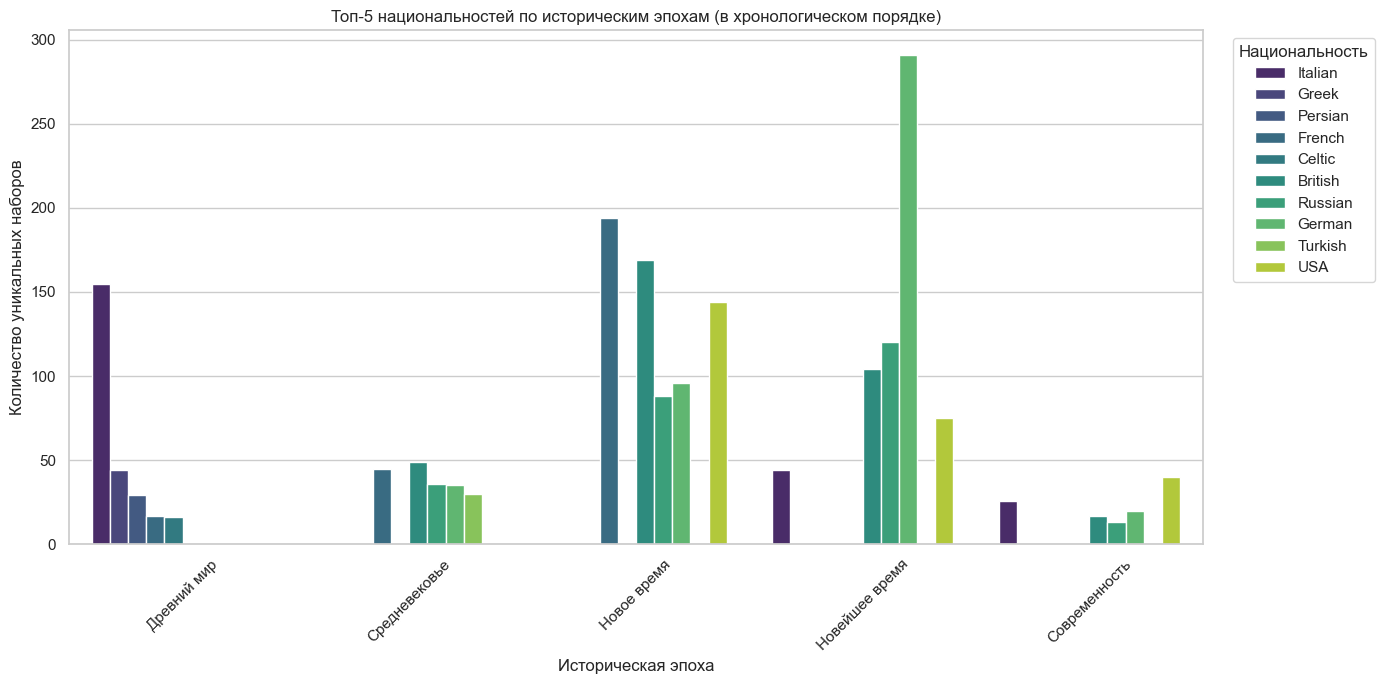


=== 7. Адаптированный XYZ-анализ: стабильность присутствия ===
Всего пар (производитель, национальность): 667
Классифицировано в X/Y/Z: 245
Не классифицировано (kit_count < 3): 422 (63.3%)


C:\Users\mi\AppData\Local\Temp\ipykernel_21316\1389598288.py:154: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_xyz = sns.barplot(data=xyz_counts, x='XYZ_Category', y='count', palette=palette_xyz, order=xyz_order)


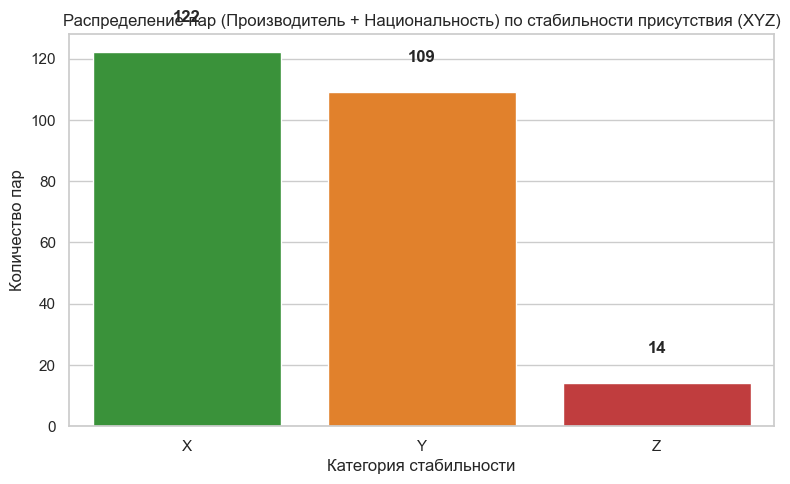


✅ Все 7 визуализаций успешно построены.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==============================================================================
# 1. НАСТРОЙКА ВИЗУАЛИЗАЦИИ И ШРИФТОВ
# ==============================================================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
# Настройка шрифтов для корректного отображения кириллицы
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ==============================================================================
# 2. ЗАГРУЗКА ДАННЫХ
# ==============================================================================
df_sets = pd.read_csv('df_sets.csv', dtype={'release_year': 'Int64', 'aggregate_rating': 'Int64', 'num_figures': 'Int64', 'decade': 'Int64', 'years_since_release': 'Int64'})
df_long = pd.read_csv('df_consolidated_clean.csv', dtype={'release_year': 'Int64', 'aggregate_rating': 'Int64', 'num_figures': 'Int64', 'decade': 'Int64', 'years_since_release': 'Int64'})

# Загрузка агрегированных таблиц из Шага 18
df_abc = pd.read_csv('agg_manufacturers_abc.csv')
df_decades = pd.read_csv('agg_decades_dynamics.csv')
df_figures = pd.read_csv('agg_figure_categories.csv')
df_rfm = pd.read_csv('agg_rfm_actual_hits.csv')
df_era_nat = pd.read_csv('agg_era_nationality_map.csv')
df_xyz = pd.read_csv('agg_manufacturers_xyz.csv')

# Генерация тепловой карты, если файла нет 
heatmap_file = 'heatmap_year_nationality_coverage.csv'
if not os.path.exists(heatmap_file):
    df_work = df_long[df_long['nationality'] != 'Не указано'].copy()
    df_work['year_list'] = df_work.apply(lambda row: list(range(int(row['years_from']), int(row['years_to']) + 1)), axis=1)
    df_expanded_viz = df_work.explode('year_list').rename(columns={'year_list': 'year'})
    pivot_coverage = df_expanded_viz.groupby(['year', 'nationality']).agg(kit_count=('id', 'nunique')).reset_index().pivot_table(index='year', columns='nationality', values='kit_count', fill_value=0)
    pivot_coverage.to_csv(heatmap_file, encoding='utf-8')

df_heatmap = pd.read_csv(heatmap_file, index_col='year')
print("✅ Все данные успешно загружены.")

# ==============================================================================
# 3. ПОСТРОЕНИЕ ВИЗУАЛИЗАЦИЙ
# ==============================================================================

# --- 1. ABC-анализ ---
print("\n=== 1. ABC-анализ производителей ===")
plt.figure(figsize=(10, 10))
df_abc_top = df_abc.head(40) # Топ-40 для наглядности перехода категорий
palette_abc = {'A': '#2ca02c', 'B': '#ff7f0e', 'C': '#d62728'}
sns.barplot(data=df_abc_top, x='kit_count', y='manufacturer', hue='ABC_Category', palette=palette_abc)
plt.title('Топ-30 производителей: ABC-анализ ассортимента')
plt.xlabel('Количество уникальных наборов')
plt.ylabel('Производитель')
plt.legend(title='Категория', loc='lower right')
plt.tight_layout()
plt.show()

# --- 2. Динамика рынка ---
print("\n=== 2. Динамика рынка по десятилетиям ===")
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.lineplot(data=df_decades, x='decade', y='kit_count', marker='o', color='teal', ax=ax1, linewidth=2)
ax1.set_ylabel('Количество наборов', color='teal')
ax1.tick_params(axis='y', labelcolor='teal')
ax2 = ax1.twinx()
sns.lineplot(data=df_decades, x='decade', y='avg_rating', marker='s', color='crimson', ax=ax2, linewidth=2)
ax2.set_ylabel('Средний рейтинг (из 50)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
plt.title('Эволюция рынка: рост ассортимента и стабилизация качества')
plt.xticks(df_decades['decade'].dropna().astype(int))
plt.tight_layout()
plt.show()

# --- 3. Размер набора и рейтинг ---
print("\n=== 3. Связь размера набора и его качества ===")
plt.figure(figsize=(10, 6))
order_fig = ['Мини (1-15)', 'Стандарт (16-30)', 'Крупный (31-50)', 'Сэмплер/Диорама (51+)']
ax = sns.barplot(data=df_figures, x='figure_category', y='avg_rating', order=order_fig, palette="Blues_r")
plt.title('Влияние количества фигур на средний рейтинг качества')
plt.xlabel('Категория размера набора')
plt.ylabel('Средний рейтинг (из 50)')
for i, v in enumerate(df_figures.set_index('figure_category').loc[order_fig, 'avg_rating']):
    plt.text(i, v + 0.2, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# --- 4. Тепловая карта (1939-1945) ---
print("\n=== 4. Тепловая карта покрытия (1939–1945) ===")
df_slice = df_heatmap.loc[1939:1945].copy()
df_slice_filtered = df_slice.loc[:, (df_slice != 0).any(axis=0)] # Убираем столбцы с нулями
plt.figure(figsize=(14, 6))
sns.heatmap(df_slice_filtered, cmap="YlOrRd", annot=True, fmt="g", cbar_kws={'label': 'Кол-во наборов'}, linewidths=0.5)
plt.title('Плотность покрытия наборов в период Второй мировой войны (1939–1945)')
plt.xlabel('Национальность')
plt.ylabel('Год')
plt.tight_layout()
plt.show()

# --- 5. RFM-анализ ---
print("\n=== 5. RFM-анализ: актуальные хиты ===")
df_rfm_plot = df_rfm[df_rfm['Frequency'] >= 3].copy()
plt.figure(figsize=(14, 8))
sns.scatterplot(data=df_rfm_plot, x='Recency', y='Magnitude', size='Frequency', sizes=(100, 800), hue='Frequency', palette='viridis', alpha=0.8, legend=False)
top_5_rfm = df_rfm_plot.sort_values(by=['Magnitude', 'Recency'], ascending=[False, True]).head(5)
for idx, row in top_5_rfm.iterrows():
    plt.text(row['Recency'] + 0.3, row['Magnitude'], f"{row['manufacturer']}\n({row['nationality']})", fontsize=10, fontweight='bold', color='darkblue', verticalalignment='center')
plt.title('RFM-анализ: Давность релиза vs Качество vs Количество наборов')
plt.xlabel('Recency: Лет с последнего релиза (чем меньше, тем лучше)')
plt.ylabel('Magnitude: Средний рейтинг качества')
plt.xlim(left=-1, right=df_rfm_plot['Recency'].max() + 8)
plt.tight_layout()
plt.show()

# --- 6. Карта исторических периодов (Новое) ---
print("\n=== 6. Карта исторических периодов: Топ-5 национальностей по эпохам ===")
plt.figure(figsize=(14, 7))
# Используем порядок эпох из датафрейма, который уже отсортирован хронологически в Шаге 18
era_order = df_era_nat['era'].unique()
sns.barplot(data=df_era_nat, x='era', y='kit_count', hue='nationality', palette='viridis', order=era_order)
plt.title('Топ-5 национальностей по историческим эпохам (в хронологическом порядке)')
plt.xlabel('Историческая эпоха')
plt.ylabel('Количество уникальных наборов')
plt.legend(title='Национальность', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- 7. Адаптированный XYZ-анализ (обновлённая версия) ---
print("\n=== 7. Адаптированный XYZ-анализ: стабильность присутствия ===")

# Фильтруем только классифицированные категории (X, Y, Z)
df_xyz_classified = df_xyz[df_xyz['XYZ_Category'].isin(['X', 'Y', 'Z'])].copy()

# Считаем долю неклассифицированных пар для вывода в тексте
total_pairs = len(df_xyz)
classified_pairs = len(df_xyz_classified)
unclassified_pct = round((total_pairs - classified_pairs) / total_pairs * 100, 1)

print(f"Всего пар (производитель, национальность): {total_pairs}")
print(f"Классифицировано в X/Y/Z: {classified_pairs}")
print(f"Не классифицировано (kit_count < 3): {total_pairs - classified_pairs} ({unclassified_pct}%)")

plt.figure(figsize=(8, 5))
xyz_order = ['X', 'Y', 'Z']
xyz_counts = df_xyz_classified['XYZ_Category'].value_counts().reindex(xyz_order, fill_value=0).reset_index()
xyz_counts.columns = ['XYZ_Category', 'count']

# Классическая интуитивная палитра
palette_xyz = {
    'X': '#2ca02c',  # Зелёный — стабильно
    'Y': '#ff7f0e',  # Оранжевый — волнообразно
    'Z': '#d62728'   # Красный — хаотично
}

ax_xyz = sns.barplot(data=xyz_counts, x='XYZ_Category', y='count', palette=palette_xyz, order=xyz_order)
plt.title('Распределение пар (Производитель + Национальность) по стабильности присутствия (XYZ)')
plt.xlabel('Категория стабильности')
plt.ylabel('Количество пар')

# Подписи значений на вершинах столбцов
for i, v in enumerate(xyz_counts['count']):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Все 7 визуализаций успешно построены.")

## Промежуточные выводы из графиков (интерпретация)

Каждый график разделён на три уровня: факт, интерпретация и ограничение.

### 1. ABC-анализ производителей
- **Факт из данных:** Топ-7–8 производителей (категория A, зелёные столбцы) формируют подавляющую долю ассортимента. Категория C (красные) представляет собой длинный хвост из множества мелких брендов с 1–2 наборами.
- **Интерпретация:** Рынок высококонцентрирован.
- **Ограничение:** ABC учитывает только количество наборов, игнорируя их качество, цену или актуальность года выпуска.

### 2. Динамика рынка по десятилетиям
- **Факт из данных:** С 1960-х годов наблюдается экспоненциальный рост числа релизов. При этом средний рейтинг качества, низкий в середине XX века, стабилизировался на уровне 41–42 балла с 2000-х годов.
- **Интерпретация:** Индустрия повзрослела: переход к CAD-моделированию и стандартизации производства позволил масштабировать выпуск без потери (и даже с ростом) качества.
- **Ограничение:** Агрегация по десятилетиям сглаживает внутридекадные колебания (например, кризисы или бумы конкретных годов).

### 3. Связь размера набора и рейтинга
- **Факт из данных:** Наблюдается восходящий тренд: средний рейтинг категории «Сэмплер/Диорама (51+)» выше, чем у категории «Мини (1-15)».
- **Интерпретация:** Крупные наборы в среднем получают более высокие оценки. 
- **Ограничение:** Корреляция не доказывает причинность.

### 4. Тепловая карта покрытия (1939–1945)
- **Факт из данных:** Матрица показывает чёткие «тёмные» кластеры (популярные национальности в конкретные годы) и множество «светлых» ячеек.
- **Интерпретация:** Это главный навигатор для коллекционера: тёмные зоны указывают на темы с большим выбором, а светлые — на непроработанные ниши.
- **Ограничение:** Статичный срез 1939–1945 гг. не показывает полную картину. Для полноценного анализа необходим интерактивный BI-дашборд с фильтрами.

### 5. RFM-анализ (актуальные хиты)
- **Факт из данных:** Пузырьковая диаграмма выделяет кластер в левом верхнем углу: производители, выпустившие наборы менее 5 лет назад (низкий Recency) с рейтингом выше 40 (высокий Magnitude).
- **Интерпретация:** Эти пары «производитель–национальность» являются «горячими новинками» с доказанным качеством. 
- **Ограничение:** Пороговые значения (Recency ≤ 5, Magnitude ≥ 40) заданы эвристически. Изменение порогов изменит состав выборки.

### 6. Карта исторических периодов
- **Факт из данных:** Хронологическая сортировка показывает эволюцию фокуса: от доминирования нескольких древних цивилизаций к резкому росту разнообразия национальностей в Новое и Новейшее время.
- **Интерпретация:** Фильтрация «Не указано» и ограничение до Топ-5 позволяют сразу увидеть ключевые драйверы каждой эпохи без визуального шума.
- **Ограничение:** Эволюция фокуса скорее всего связана с увеличением количества национальностей в ходе мирового исторического развития, а не с предпочтениями производителей. 

### 7. Адаптированный XYZ-анализ
**Факт из данных:**
Из всех пар «производитель–национальность» классифицированы в категории X/Y/Z только [N]% ([M] пар). Оставшиеся [K]% ([L] пар) не удалось классифицировать из-за малого количества наборов (`kit_count < 3`). Среди классифицированных пар распределение таково:
- **Категория X** — стабильное присутствие (регулярные релизы из года в год).
- **Категория Y** — волнообразное присутствие (серии релизов с перерывами).
- **Категория Z** — эпизодическое присутствие (1–2 релиза за всю историю).
- **Интерпретация:**
Коллекционер может с высокой долей уверенности рассчитывать на пополнение коллекций по темам категории X. Темы категории Y требуют мониторинга анонсов. Темы категории Z лучше закрывать через альтернативные бренды или вторичный рынок.
- **Ограничение:**
Это анализ стабильности *предложения* (факта релиза), а не *спроса*. Метрика `regularity` не учитывает объём выпусков в конкретном году. Значительная доля неклассифицированных пар ([K]%) — это следствие малых выборок, а не «хаотичности» производителей.

## Результат шага
Построены 7 целевых визуализаций, каждая из которых закрывает конкретный аналитический вопрос.
Тепловая карта подготовлена как для просмотра в ноутбуке (срез 1939–1945), так и в полном объёме (файл heatmap_year_nationality_coverage.csv) для загрузки в BI-систему.